$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
$$

INSERT_setup_intro

INSERT_problem_a

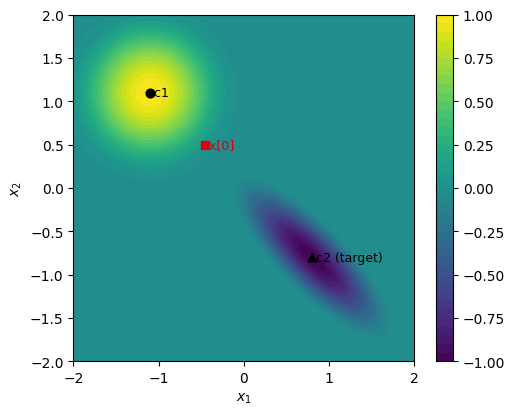

In [1]:
#| label: setup_data
import numpy as np
import matplotlib.pyplot as plt

c1 = np.array([-1.1, 1.1])
c2 = np.array([0.8, -0.8])
S2 = np.array([[1.1, -0.9], [-0.9, 1.1]])
S2_inv = np.linalg.inv(S2)


def rho(u):
    """Biweight (quartic) kernel: (1 - u^2)^2 for |u| < 1, else 0."""
    return (1 - u ** 2) ** 2 if abs(u) < 1 else 0.0


def dist1(x):
    return float(np.sqrt((x - c1) @ (x - c1)))           # Euclidean (S1 = I)


def dist2(x):
    return float(np.sqrt((x - c2) @ S2_inv @ (x - c2)))  # Mahalanobis


def f(x):
    """w_1 = +1, w_2 = -1."""
    x = np.asarray(x, dtype=float)
    return rho(dist1(x)) - rho(dist2(x))


# Surface plot on [-2, 2] x [-2, 2]
grid = np.arange(-2, 2 + 0.01, 0.01)
T1, T2 = np.meshgrid(grid, grid)
Z = np.array([[f(np.array([t1, t2])) for t1 in grid] for t2 in grid])


def plot_landscape(ax):
    """Render the contour with c_1, c_2, x[0] landmarks (reused by d, f)."""
    cs = ax.contourf(T1, T2, Z, levels=np.arange(-1.0, 1.0 + 0.05, 0.05))
    ax.scatter(*c1, color="black", s=40, marker="o", zorder=3)
    ax.annotate(" c1", c1, color="black", fontsize=9, va="center")
    ax.scatter(*c2, color="black", s=40, marker="^", zorder=3)
    ax.annotate(" c2 (target)", c2, color="black", fontsize=9, va="center")
    ax.scatter(-0.45, 0.5, color="#D90012", s=40, marker="s", zorder=3)
    ax.annotate(" x[0]", (-0.45, 0.5), color="#D90012", fontsize=9, va="center")
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
    return cs


fig, ax = plt.subplots(figsize=(5.5, 4.5))
cs = plot_landscape(ax)
fig.colorbar(cs)
plt.show()

**Solution.**

INSERT_solution_a_text

INSERT_problem_b

**Solution.**

INSERT_solution_b_text

INSERT_problem_c

**Solution.**

INSERT_solution_c_text

INSERT_problem_d

x[0] = (-0.4500, +0.5000)
x[1] = (-0.3652, +0.4217)
x[2] = (-0.3652, +0.4217)
grad at x[1] = (+0.0000, +0.0000)  -- identically zero -> stuck


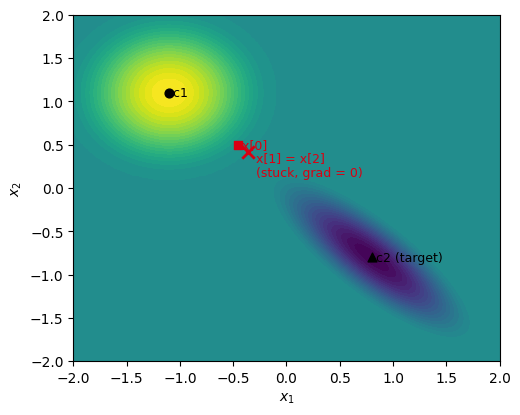

In [2]:
#| label: solution_d_code
def grad(x):
    """Gradient of f. By (b), at most one basin's support is active at any x."""
    x = np.asarray(x, dtype=float)
    d1_sq = (x - c1) @ (x - c1)
    d2_sq = (x - c2) @ S2_inv @ (x - c2)
    if d1_sq < 1:
        # Inside c_1 support: gradient of +rho(||x - c_1||)
        return -4 * (1 - d1_sq) * (x - c1)
    elif d2_sq < 1:
        # Inside c_2 support: gradient of -rho(||x - c_2||_S2); sign flipped
        return 4 * (1 - d2_sq) * (S2_inv @ (x - c2))
    else:
        return np.zeros(2)   # dead zone: gradient identically zero


alpha = 0.15
x0 = np.array([-0.45, 0.5])
x1 = x0 - alpha * grad(x0)
x2 = x1 - alpha * grad(x1)

print(f"x[0] = ({x0[0]:+.4f}, {x0[1]:+.4f})")
print(f"x[1] = ({x1[0]:+.4f}, {x1[1]:+.4f})")
print(f"x[2] = ({x2[0]:+.4f}, {x2[1]:+.4f})")
g1 = grad(x1)
print(f"grad at x[1] = ({g1[0]:+.4f}, {g1[1]:+.4f})  "
      "-- identically zero -> stuck")

# Visualize the stuck-iterate situation.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_landscape(ax)
ax.annotate("", xy=x1, xytext=x0,
            arrowprops=dict(arrowstyle="->", color="#D90012", lw=1.2))
ax.scatter(*x1, color="#D90012", s=80, marker="x", linewidths=2, zorder=4)
ax.annotate("  x[1] = x[2]\n  (stuck, grad = 0)", x1, color="#D90012",
            fontsize=9, va="top")
plt.show()

INSERT_solution_d_text

INSERT_problem_e

**Solution.**

INSERT_solution_e_text

INSERT_problem_f

INSERT_momentum_intuition_note

x[15] = (+0.7831, -0.7951), f = -0.9990  (target c_2 = (+0.8000, -0.8000), f = -1)


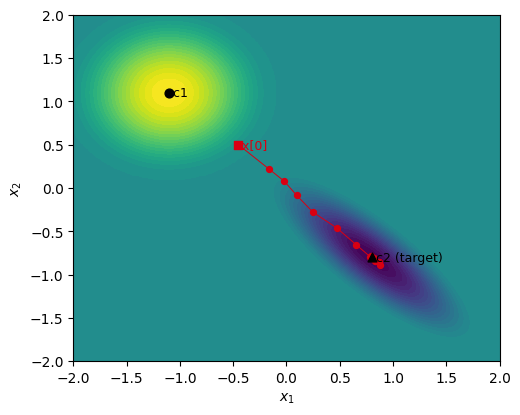

In [3]:
#| label: solution_f_code
alpha = 0.15
phi = 0.5
v = np.array([0.4, -0.4])
x = np.array([-0.45, 0.5])

xs = [x.copy()]
for _ in range(15):
    v = phi * v - alpha * grad(x)
    x = x + v
    xs.append(x.copy())
trace = np.array(xs)

print(f"x[15] = ({x[0]:+.4f}, {x[1]:+.4f}), f = {f(x):+.4f}  "
      f"(target c_2 = ({c2[0]:+.4f}, {c2[1]:+.4f}), f = -1)")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_landscape(ax)
ax.plot(trace[:, 0], trace[:, 1], color="#D90012", linewidth=0.7)
ax.scatter(trace[:, 0], trace[:, 1], color="#D90012", s=18)
plt.show()

INSERT_solution_f_text